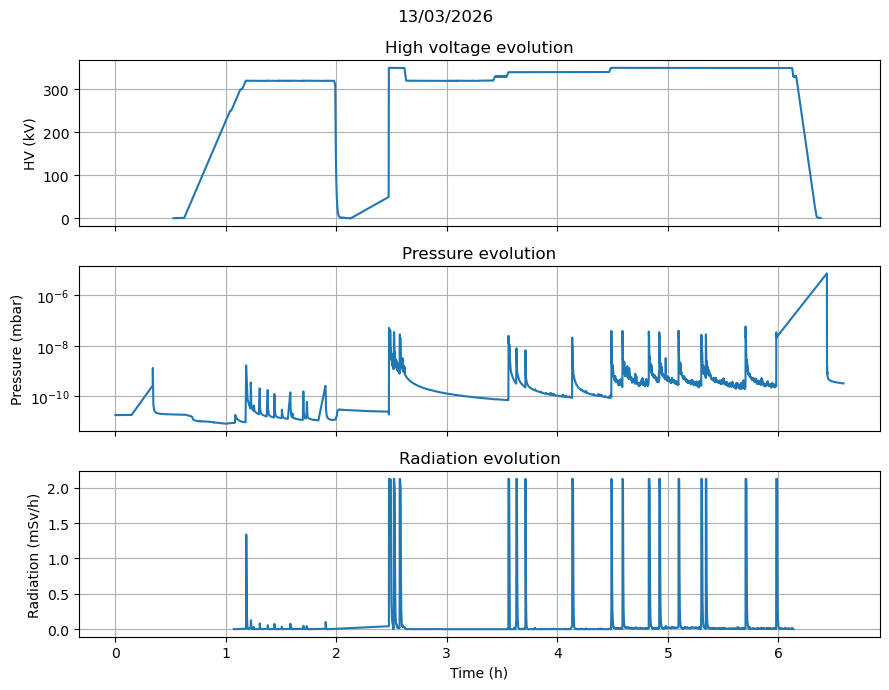

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#Lecture des fichiers CSV et des colonnes de temps
dfV = pd.read_csv("Voltage.csv", sep=";") #On lit le fichier des tensions
dfV["Time"] = pd.to_datetime(
    dfV["Time"],
    format="%Y.%m.%d %H:%M:%S")

dfP = pd.read_csv("Pressure.csv", sep=";") #On lit le fichier des pressions
dfP["Time"] = pd.to_datetime(
    dfP["Time"],
    format="%Y.%m.%d %H:%M:%S")

dfR = pd.read_csv("Radiation.csv", sep=";") #On lit le fichier des radiations
dfR["Time"] = pd.to_datetime(
    dfR["Time"],
    format="%Y.%m.%d %H:%M:%S")

#Définition du temps inital global
dfs=[dfV,dfP,dfR]
t0i = min(df["Time"].min() for df in dfs)

#Création du nouvel axe de temps pour chaque série de données
for df in dfs:
    df["t"] = (df["Time"] - t0i).dt.total_seconds()
    df["t_h"] = df["t"] / 3600
    df["t_s"] = df["Time"]

#Nettoyage du graphe de pression
pressure_threshold = 1
dfP_clean = dfP.copy()
dfP_clean.loc[dfP_clean["Pressure"] > pressure_threshold, "Pressure"] = np.nan

#Plots des données
fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(9, 7))

axes[0].plot(dfV["t_h"], dfV["Voltage"])
axes[0].set_ylabel("HV (kV)")
axes[0].set_title("High voltage evolution")
axes[0].grid(True)

axes[1].plot(dfP["t_h"], dfP_clean["Pressure"])
axes[1].set_ylabel("Pressure (mbar)")
axes[1].set_yscale("log")
axes[1].set_title("Pressure evolution")
axes[1].grid(True)

axes[2].plot(dfR["t_h"], dfR["Radiation"])
axes[2].set_ylabel("Radiation (mSv/h)")
axes[2].set_xlabel("Time (h)")
axes[2].set_title("Radiation evolution")
axes[2].grid(True)
fig.suptitle("13/03/2026",horizontalalignment='center')
plt.tight_layout()
plt.show()

Nb pics détectés : 21


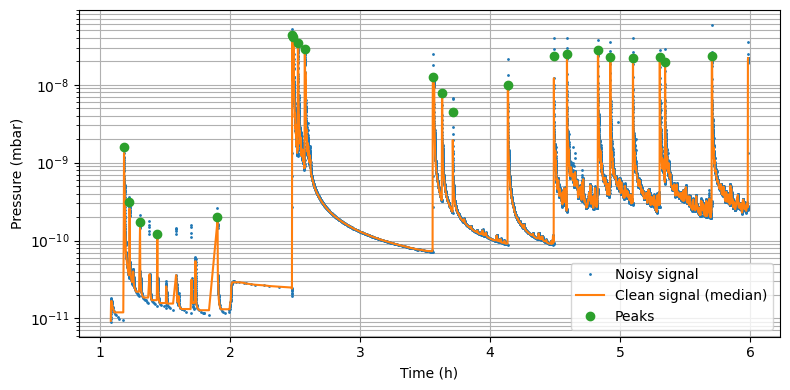

In [3]:
#Détection automatique des pics
from scipy.signal import find_peaks

t_d = 1
t_f = 6

dfP_clean["HV"] = dfV["Voltage"]
dt = np.median(np.diff(dfP_clean["t_h"]*3600))
cache2 = (dfP_clean["t_h"] >= t_d) & (dfP_clean["t_h"] <= t_f)
dfP_clean_bis = dfP_clean.loc[cache2, ["t_h", "Pressure"]].dropna().copy()
dfP_clean_bis["HV"] = dfP_clean["HV"]

sec_lis = 10  #On choisit le nombre de secondes à lisser (à ajuster en fct de si on veut enlever juste les pics courts ou plus de fluctuations)
win = int(max(5, round(sec_lis / dt)))  #On convertit en nombre de points et on impose au moins 5 points
if win % 2 == 0:
   win += 1  #On impose que la fenêtre soit impaire (mieux centrée)

dfP_clean_bis["P_med"] = dfP_clean["Pressure"].rolling(win, center=True, min_periods=1).median() #Parcourt l'ensemble des points et pour chacun,
dfP_clean_bis["logP_med"] = np.log(dfP_clean_bis["P_med"])
dfP_clean_bis["t_s"] = dfP_clean_bis["t_h"]*3600

dist = 60 #secondes entre deux pics consécutifs (si deux pics sont plus proches, ils seront fusionnés)
dist_pts = int(dist/dt) #Distance en nombre de points

proem=1

peaks, props = find_peaks(dfP_clean_bis["logP_med"].to_numpy(), prominence=proem, distance=dist_pts)
df_peaks = dfP_clean_bis.iloc[peaks][["t_h", "t_s", "Pressure"]].copy()
df_peaks["prominence"] = props["prominences"]
print("Nb pics détectés :", len(df_peaks))
df_peaks.head()

plt.figure(figsize=(8,4))
plt.semilogy(dfP_clean_bis["t_h"], dfP_clean_bis["Pressure"], ".", markersize=2, label="Noisy signal")
plt.semilogy(dfP_clean_bis["t_h"], np.exp(dfP_clean_bis["logP_med"]), "-", label="Clean signal (median)")
plt.semilogy(df_peaks["t_h"], df_peaks["Pressure"], "o", label="Peaks")
plt.xlabel("Time (h)")
plt.ylabel("Pressure (mbar)")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

Pic à t0 = 4262.0 impossible à fitter. Raisons: {'empty': 0, 'few_points': 0, 'not_decreasing': 0, 'bad_dt': 0, 'few_after_cut': 0, 'fit_fail': 0, 'bounds_or_tau': 0, 'nan_r2': 0, 'bad_r2': 0, 'Voltage': 14}
Pic à t0 = 4413.0 impossible à fitter. Raisons: {'empty': 0, 'few_points': 0, 'not_decreasing': 0, 'bad_dt': 0, 'few_after_cut': 0, 'fit_fail': 0, 'bounds_or_tau': 0, 'nan_r2': 0, 'bad_r2': 0, 'Voltage': 28}
Pic à t0 = 4704.0 impossible à fitter. Raisons: {'empty': 0, 'few_points': 0, 'not_decreasing': 0, 'bad_dt': 0, 'few_after_cut': 0, 'fit_fail': 0, 'bounds_or_tau': 0, 'nan_r2': 0, 'bad_r2': 0, 'Voltage': 46}
Pic à t0 = 5182.0 impossible à fitter. Raisons: {'empty': 0, 'few_points': 0, 'not_decreasing': 0, 'bad_dt': 0, 'few_after_cut': 0, 'fit_fail': 0, 'bounds_or_tau': 0, 'nan_r2': 0, 'bad_r2': 0, 'Voltage': 90}
Pic à t0 = 6846.0 impossible à fitter. Raisons: {'empty': 0, 'few_points': 0, 'not_decreasing': 0, 'bad_dt': 0, 'few_after_cut': 0, 'fit_fail': 0, 'bounds_or_tau': 0, '

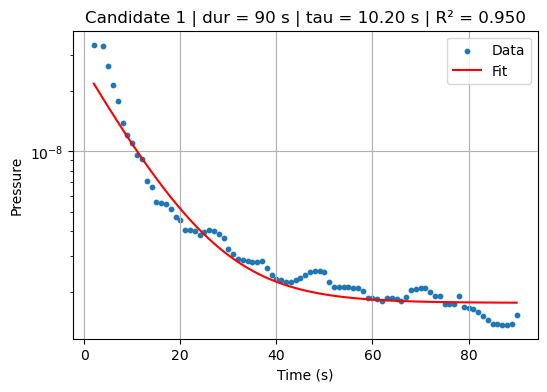

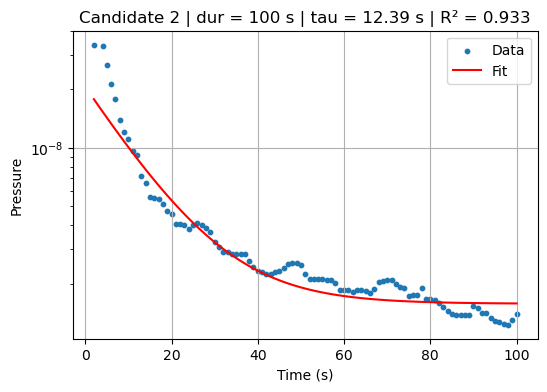

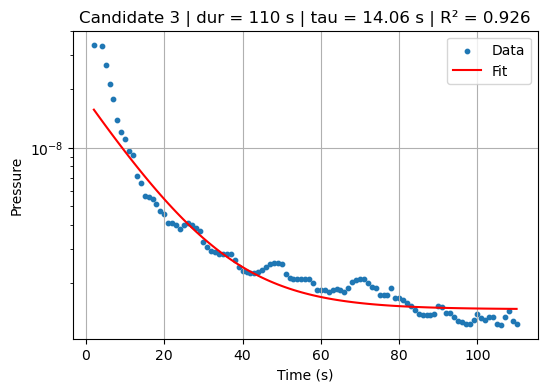

Choisir un candidat (1-3) ou 'n' pour rejeter ce pic :  n


Pic rejeté.
Pic à t0 = 9268.0 impossible à fitter. Raisons: {'empty': 0, 'few_points': 0, 'not_decreasing': 0, 'bad_dt': 0, 'few_after_cut': 0, 'fit_fail': 0, 'bounds_or_tau': 28, 'nan_r2': 0, 'bad_r2': 0, 'Voltage': 62}

Pic à t0 = 12816.0 s
13 candidats valides trouvés.
Affichage des meilleurs candidats :


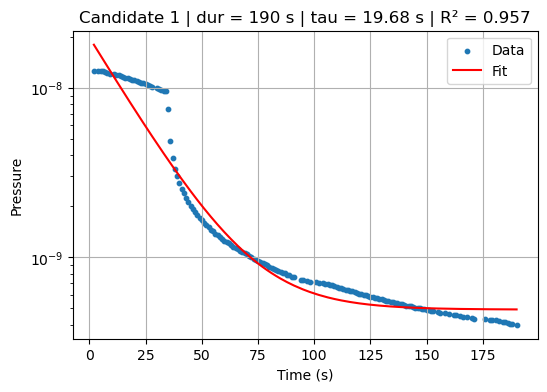

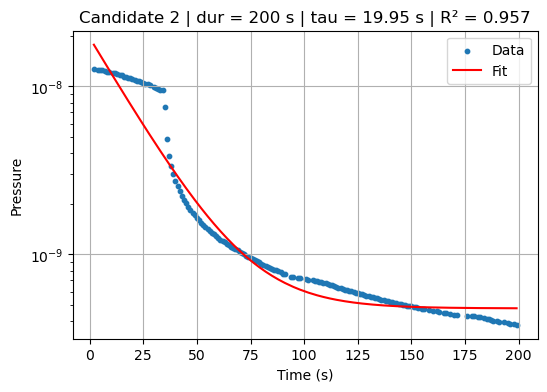

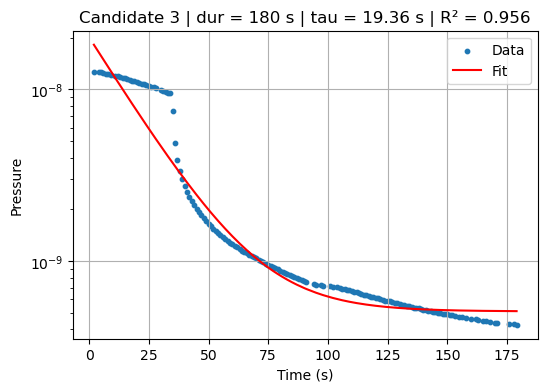

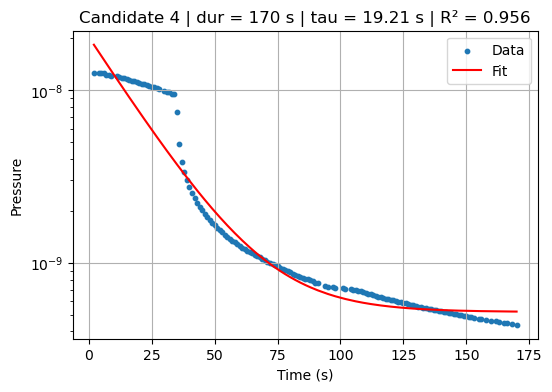

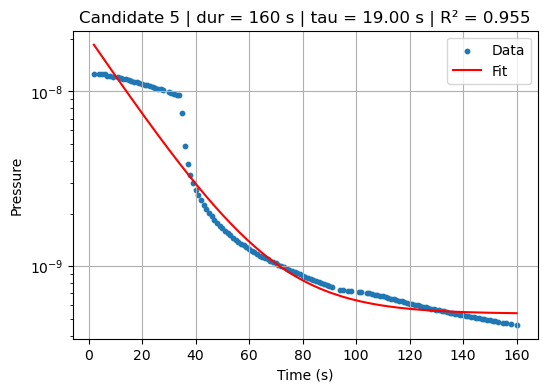

Choisir un candidat (1-5) ou 'n' pour rejeter ce pic :  n


Pic rejeté.

Pic à t0 = 13069.0 s
4 candidats valides trouvés.
Affichage des meilleurs candidats :


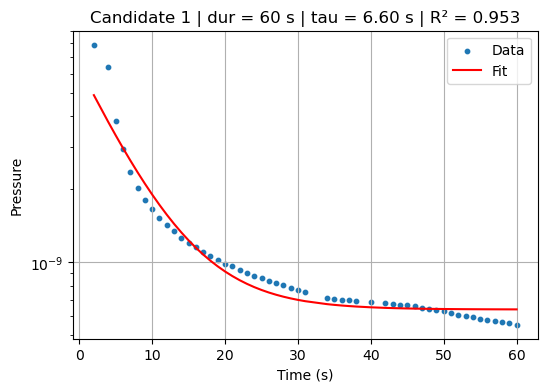

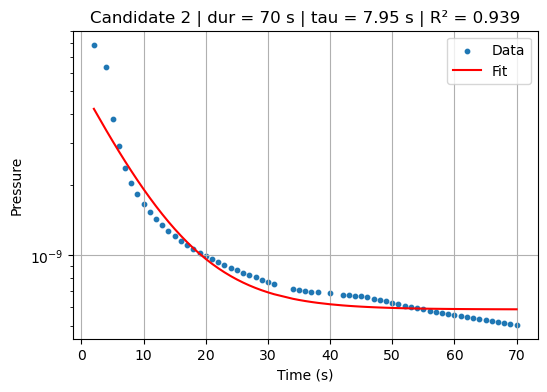

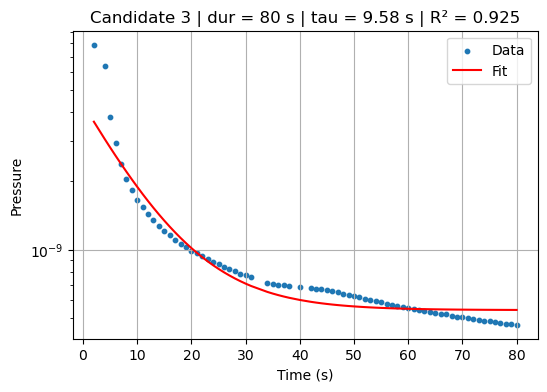

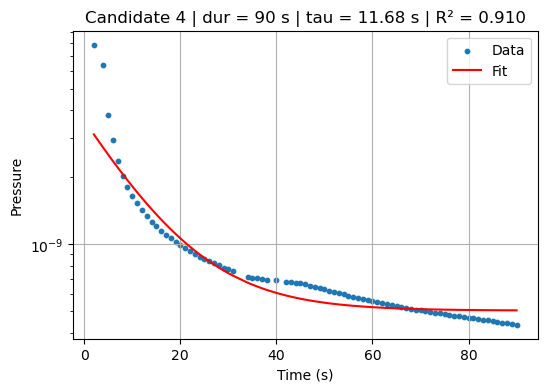

Choisir un candidat (1-4) ou 'n' pour rejeter ce pic :  n


Pic rejeté.

Pic à t0 = 13362.0 s
6 candidats valides trouvés.
Affichage des meilleurs candidats :


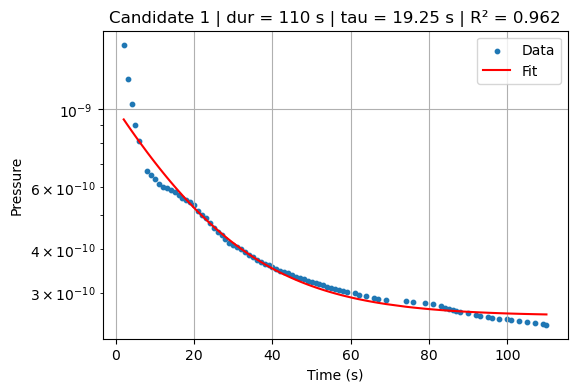

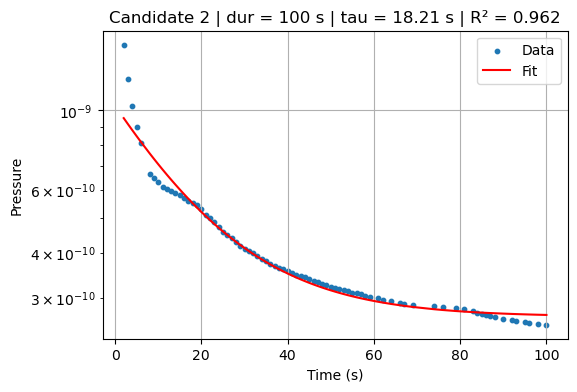

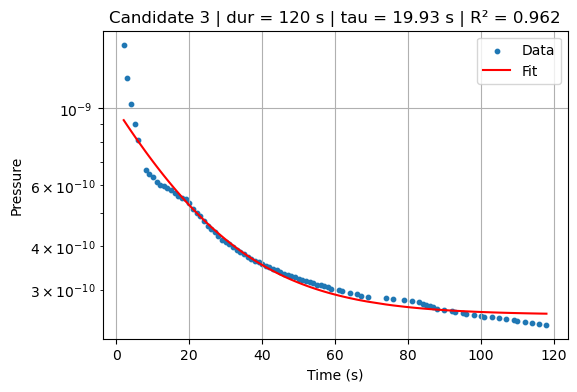

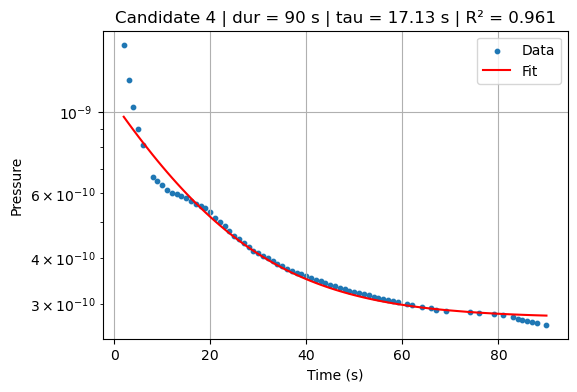

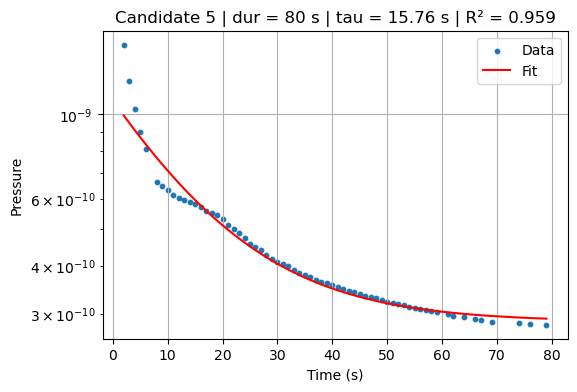

Choisir un candidat (1-5) ou 'n' pour rejeter ce pic :  n


Pic rejeté.

Pic à t0 = 14892.0 s
4 candidats valides trouvés.
Affichage des meilleurs candidats :


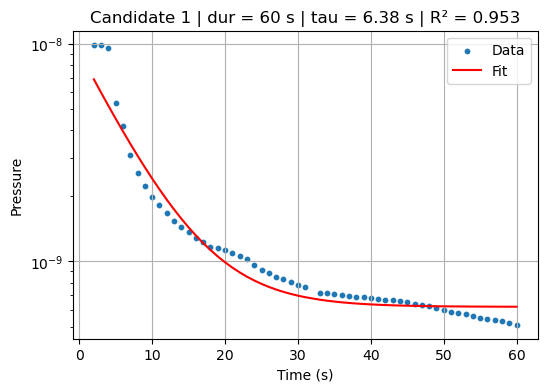

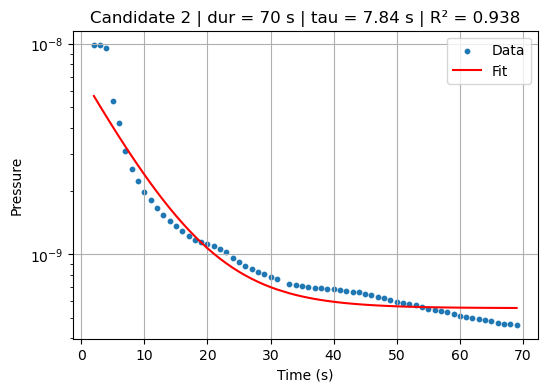

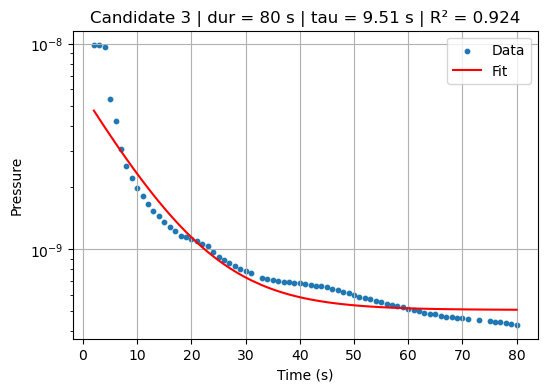

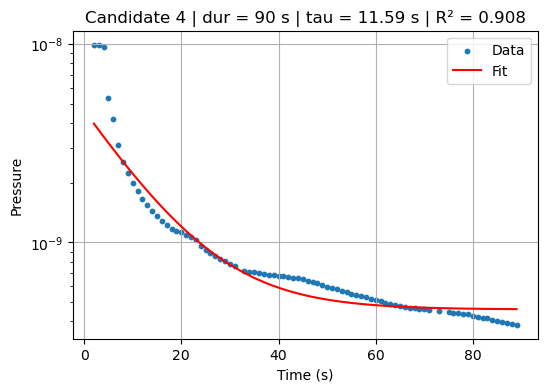

Choisir un candidat (1-4) ou 'n' pour rejeter ce pic :  1


Fit accepté : candidat 1

Pic à t0 = 16160.0 s
1 candidats valides trouvés.
Affichage des meilleurs candidats :


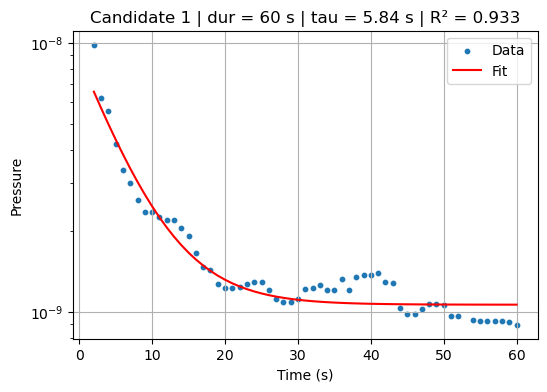

Choisir un candidat (1-1) ou 'n' pour rejeter ce pic :  1


Fit accepté : candidat 1
Pic à t0 = 16523.0 impossible à fitter. Raisons: {'empty': 0, 'few_points': 5, 'not_decreasing': 0, 'bad_dt': 0, 'few_after_cut': 0, 'fit_fail': 0, 'bounds_or_tau': 67, 'nan_r2': 0, 'bad_r2': 13, 'Voltage': 0}

Pic à t0 = 17385.0 s
10 candidats valides trouvés.
Affichage des meilleurs candidats :


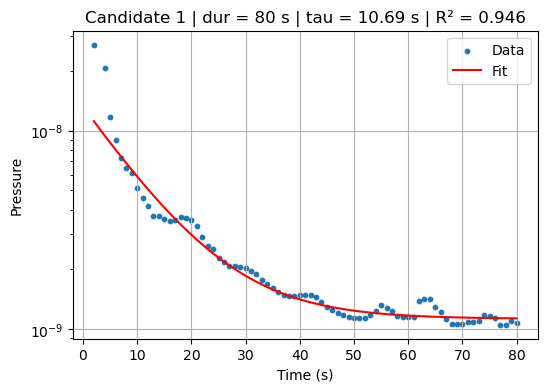

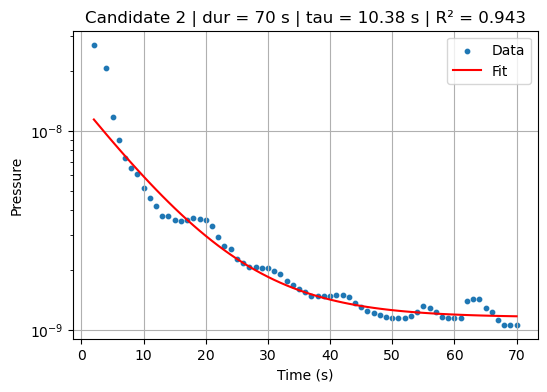

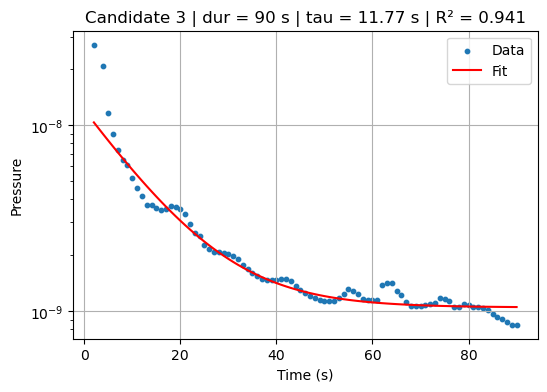

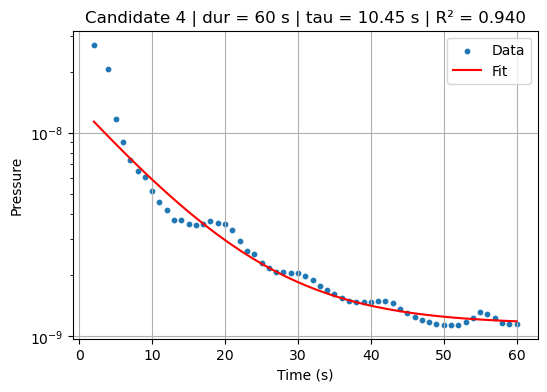

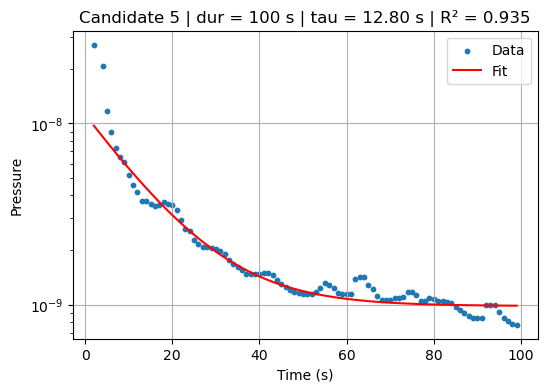

Choisir un candidat (1-5) ou 'n' pour rejeter ce pic :  n


Pic rejeté.

Pic à t0 = 17723.0 s
3 candidats valides trouvés.
Affichage des meilleurs candidats :


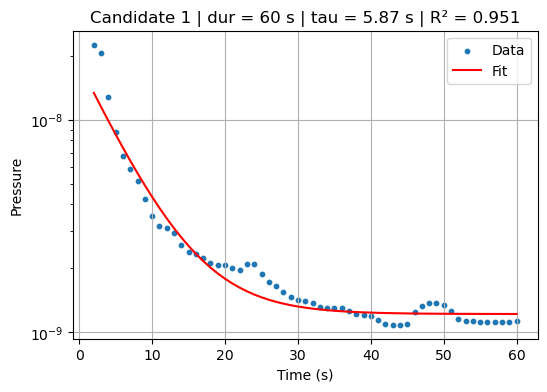

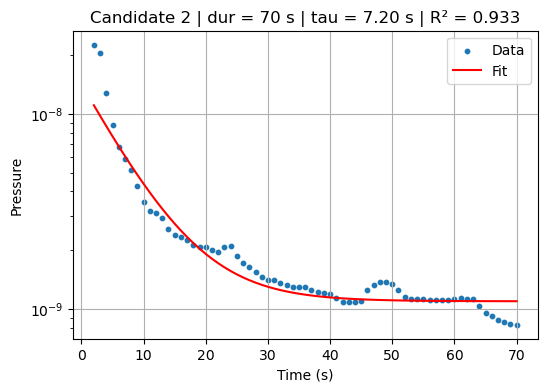

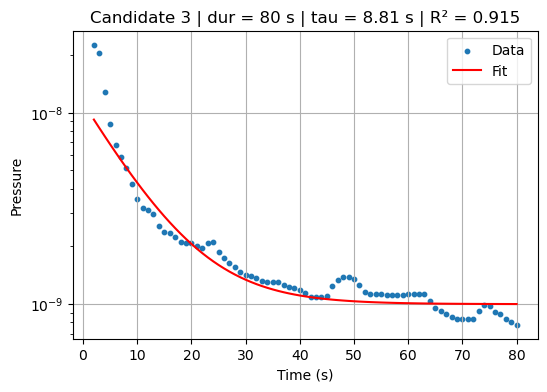

Choisir un candidat (1-3) ou 'n' pour rejeter ce pic :  1


Fit accepté : candidat 1

Pic à t0 = 18350.0 s
4 candidats valides trouvés.
Affichage des meilleurs candidats :


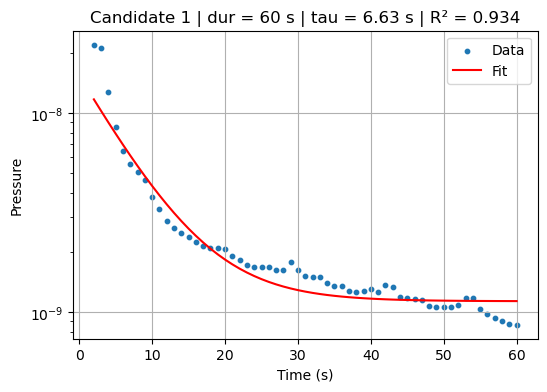

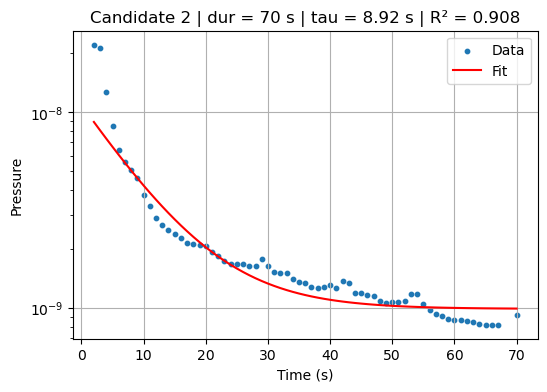

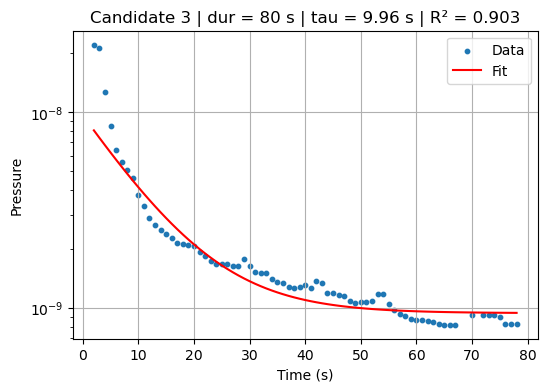

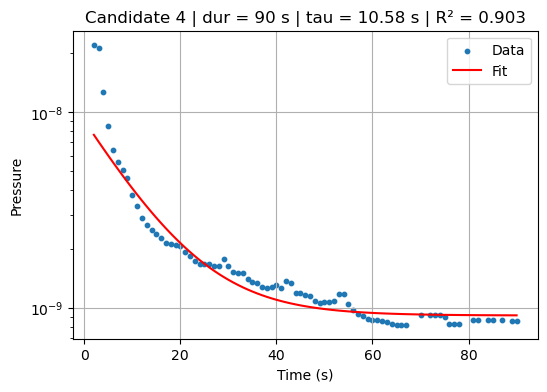

Choisir un candidat (1-4) ou 'n' pour rejeter ce pic :  3


Fit accepté : candidat 3

Pic à t0 = 19093.0 s
8 candidats valides trouvés.
Affichage des meilleurs candidats :


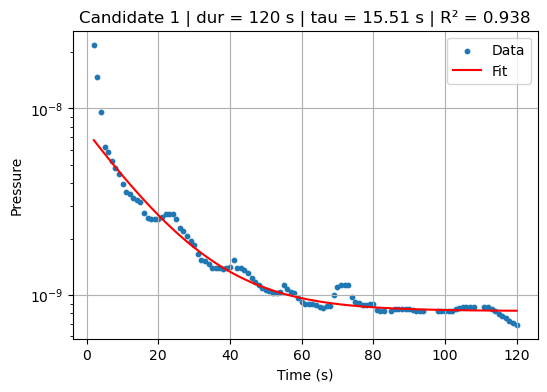

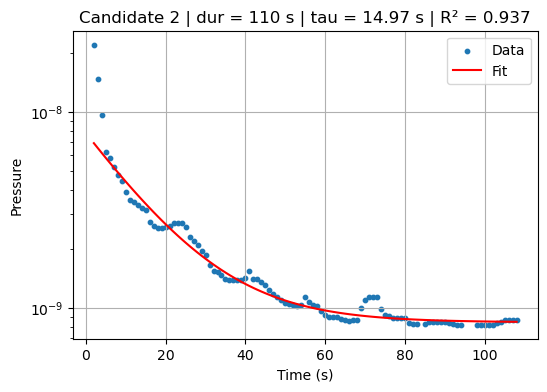

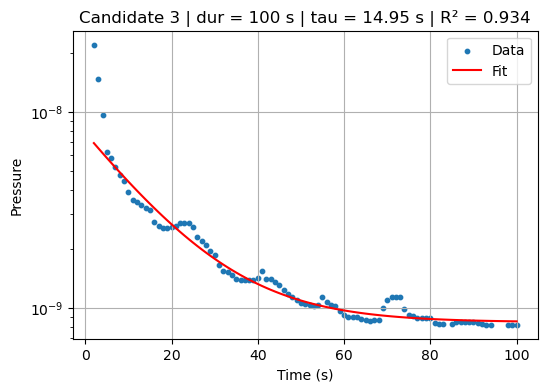

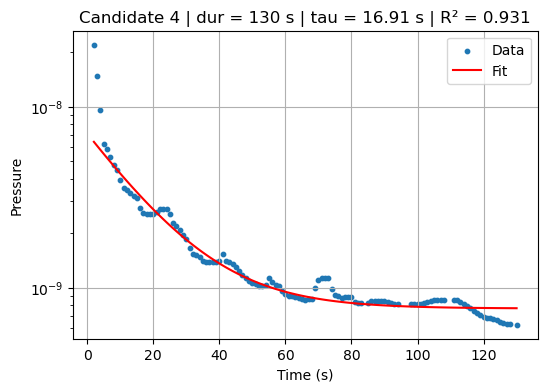

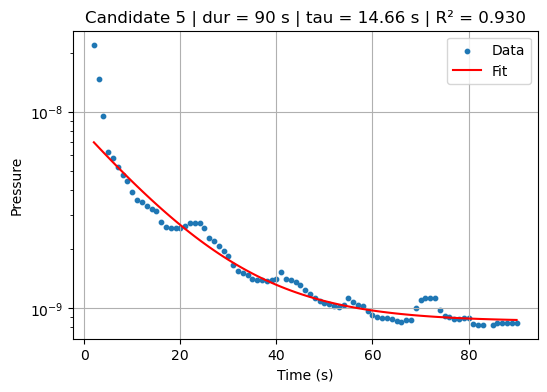

Choisir un candidat (1-5) ou 'n' pour rejeter ce pic :  n


Pic rejeté.

Pic à t0 = 19238.0 s
7 candidats valides trouvés.
Affichage des meilleurs candidats :


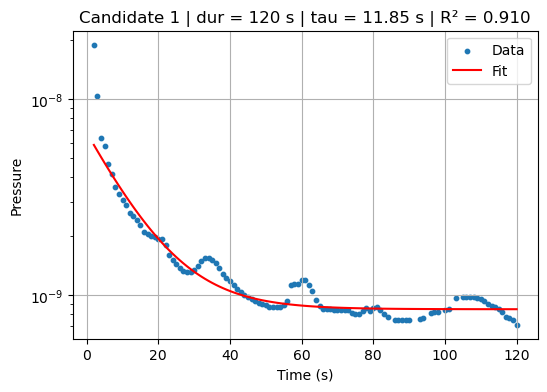

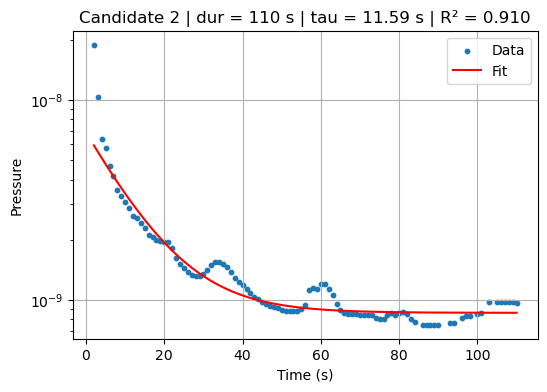

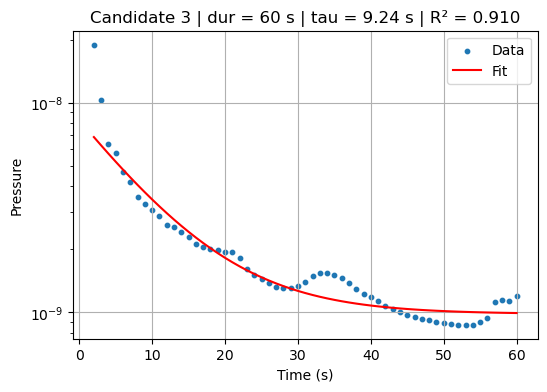

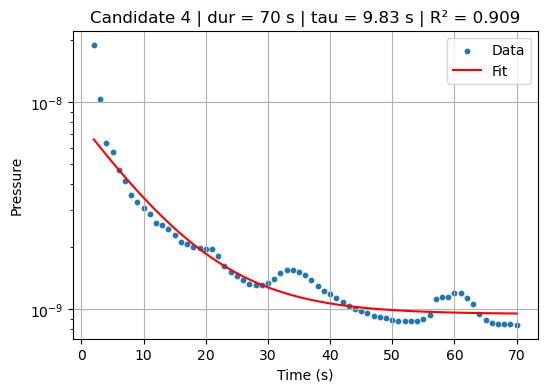

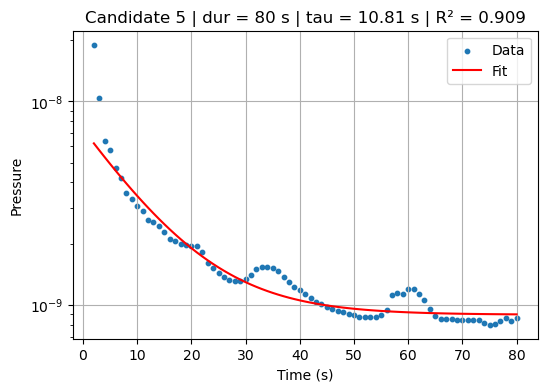

Choisir un candidat (1-5) ou 'n' pour rejeter ce pic :  4


Fit accepté : candidat 4

Pic à t0 = 20537.0 s
10 candidats valides trouvés.
Affichage des meilleurs candidats :


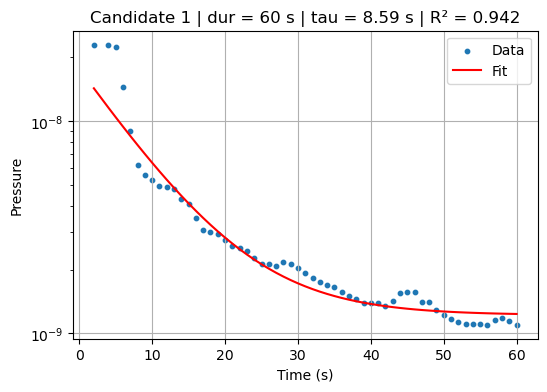

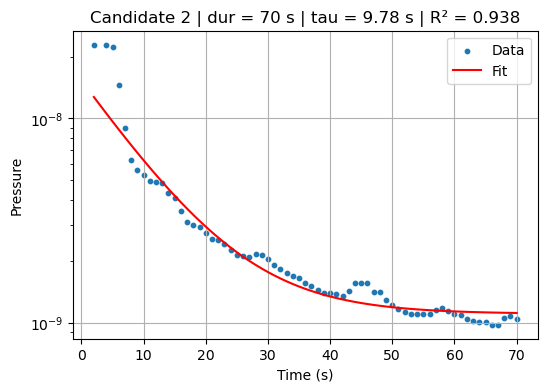

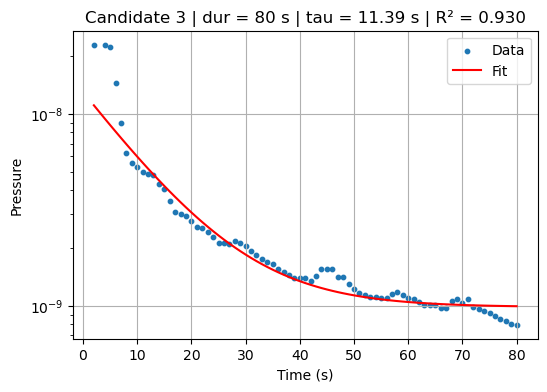

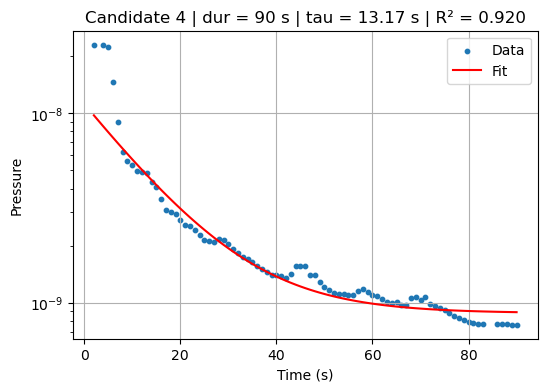

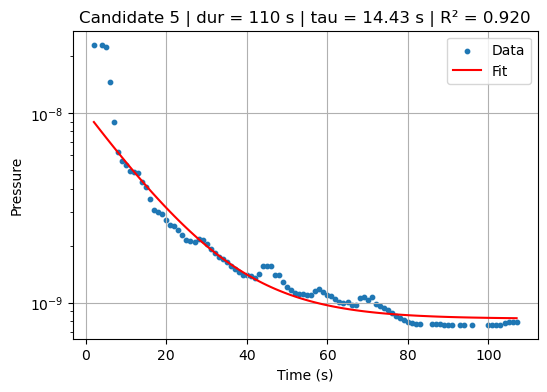

Choisir un candidat (1-5) ou 'n' pour rejeter ce pic :  1


Fit accepté : candidat 1


,t_peak_h,t_peak_s,P_peak,fit_dur_s,t_fin_h,npts,P_inf,P0,tau_s,tau_min,r2,Qualité,delta_tau_s
0,4.136667,14892.0,9.947700e-09,60,4.153333,58,6.182947e-10,8.556483e-09,6.381071,0.106351,0.953191,BON,0.424822
1,4.488889,16160.0,2.358600e-08,60,4.505556,58,1.060285e-09,7.758246e-09,5.838136,0.097302,0.933440,BON,0.445380
2,4.923056,17723.0,2.260300e-08,60,4.939722,59,1.217023e-09,1.713424e-08,5.867847,0.097797,0.951283,BON,0.386994
3,5.097222,18350.0,2.210800e-08,80,5.119444,74,9.401489e-10,8.720043e-09,9.961561,0.166026,0.903281,BON,0.819228
4,5.343889,19238.0,1.945700e-08,70,5.363333,69,9.466274e-10,6.928804e-09,9.830816,0.163847,0.909347,BON,0.755903
5,5.704722,20537.0,2.331700e-08,60,5.721389,58,1.220684e-09,1.649688e-08,8.591114,0.143185,0.941941,BON,0.605155


In [3]:
#Montre les 5 cinq meilleurs fits pour chaque pic et demande de choisir lequel on veut ou de refuser si aucun ne convient
from scipy.optimize import curve_fit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Exp seule
d_min = 10 #s
d_max = 15*60 #s
d_step = 10 #s
margin = 10 #s
r2_target = 0.90
tau_min, tau_max = 3, 20
n_best = 5 #Nombre de candidats à afficher
windows = []
t_peaks = df_peaks["t_s"].to_numpy()

def mono(t, P_inf, P0, tau):
    return P_inf + P0 * np.exp(-t / tau)

for i, ev in enumerate(df_peaks.itertuples(index=False)):
    t0 = ev.t_s

    fail = {
        "empty": 0,
        "few_points": 0,
        "not_decreasing": 0,
        "bad_dt": 0,
        "few_after_cut": 0,
        "fit_fail": 0,
        "bounds_or_tau": 0,
        "nan_r2": 0,
        "bad_r2": 0,
        "Voltage": 0,}

    if i < len(t_peaks) - 1:
        t1_limit = min(t0 + d_max, t_peaks[i+1] - margin)
    else:
        t1_limit = t0 + d_max

    candidats = []
    d_max_eff = int(max(0, t1_limit - t0))

    for d in range(d_min, d_max_eff + 1, d_step):
        seg = dfP_clean_bis[
            (dfP_clean_bis["t_s"] >= t0) &
            (dfP_clean_bis["t_s"] <= t0 + d)].copy()

        if seg.empty:
            fail["empty"] += 1
            continue

        seg = (
            seg.groupby("t_s", as_index=False)[["P_med", "HV"]]
            .median()
            .sort_values("t_s"))

        #Vérification tension constante
        V_start = seg["HV"].iloc[0]
        V_end = seg["HV"].iloc[-1]

        if abs(V_start - V_end) > 1:
            fail["Voltage"] += 1
            continue

        x = seg["t_s"].to_numpy()
        y = seg["P_med"].to_numpy()
        x = x - x[0]

        #Durée minimale réelle
        if x[-1] < 60:
            fail["few_points"] += 1
            continue

        if y[-1] > 1.01 * y[0]:
            fail["not_decreasing"] += 1
            continue

        dt_all = np.diff(x)
        dt = np.median(dt_all)

        if (not np.isfinite(dt)) or dt <= 0:
            fail["bad_dt"] += 1
            continue
            
        t_cut = dt
        m = x > t_cut
        x2, y2 = x[m], y[m]

        if len(x2) < 12:
            fail["few_after_cut"] += 1
            continue
            
        if not np.all(np.isfinite(x2)) or not np.all(np.isfinite(y2)):
            fail["fit_fail"] += 1
            continue

        #Initial guesses
        P_inf0 = max(np.median(y2[-10:]), 0)
        P0_0 = max(y2[0] - P_inf0, 1e-15)
        tau0 = max((x2[-1] - x2[0]) / 3, 1e-6)
        p0 = [P_inf0, P0_0, tau0]
        lower = [0, 0, 1e-6]
        upper = [np.inf, np.inf, np.inf]

        try:
            sigma = np.maximum(y2, 1e-15)

            params, cv = curve_fit(
                mono,
                x2,
                y2,
                p0=p0,
                bounds=(lower, upper),
                sigma=sigma,
                absolute_sigma=False,
                maxfev=20000)

            P_inf, P0, tau = params

            if not (tau_min < tau < tau_max):
                fail["bounds_or_tau"] += 1
                continue

            if (P_inf < 0) or (P0 < 0) or (tau <= 0):
                fail["bounds_or_tau"] += 1
                continue

            yfit = mono(x2, *params)

            if yfit[-1] >= yfit[0]:
                fail["not_decreasing"] += 1
                continue

            if np.any(y2 <= 0) or np.any(yfit <= 0):
                fail["nan_r2"] += 1
                continue

            #R2 logarithmique
            ylog = np.log(y2)
            yfitlog = np.log(yfit)
            ss_res = np.sum((ylog - yfitlog)**2)
            ss_tot = np.sum((ylog - np.mean(ylog))**2)
            r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

            if (not np.isfinite(r2)) or (r2 < 0):
                fail["nan_r2"] += 1
                continue

            if r2 < r2_target:
                fail["bad_r2"] += 1
                continue

            candidats.append({
                "dur_s": d,
                "params": params,
                "cv": cv,
                "r2": r2,
                "dt": dt,
                "npts": len(x2),
                "x2": x2,
                "y2": y2,})

        except Exception as e:
            fail["fit_fail"] += 1
            print("Erreur fit à t0 =", t0, "durée =", d, ":", repr(e))
            continue

    if len(candidats) == 0:
        print("Pic à t0 =", t0, "impossible à fitter. Raisons:", fail)
        continue

    #Tri des candidats par R2 décroissant
    candidats = sorted(candidats, key=lambda c: c["r2"], reverse=True)
    top_candidates = candidats[:n_best]
    
    print("\n" + "="*70)
    print(f"Pic à t0 = {t0:.1f} s")
    print(f"{len(candidats)} candidats valides trouvés.")
    print("Affichage des meilleurs candidats :")

    for j, cand in enumerate(top_candidates):
        P_inf, P0, tau = cand["params"]
        x2 = cand["x2"]
        y2 = cand["y2"]
        yfit = mono(x2, *cand["params"])

        plt.figure(figsize=(6, 4))
        plt.scatter(x2, y2, s=10, label="Data")
        plt.plot(x2, yfit, "r", label="Fit")
        plt.xlabel("Time (s)")
        plt.ylabel("Pressure")
        plt.yscale("log")
        plt.title(f"Candidate {j+1} | dur = {cand['dur_s']} s | " f"tau = {tau:.2f} s | R² = {cand['r2']:.3f}")
        plt.legend()
        plt.grid()
        plt.show()

    #Choix utilisateur
    while True:
        choice = input(
            f"Choisir un candidat (1-{len(top_candidates)}) ou 'n' pour rejeter ce pic : ").strip().lower()

        if choice == "n":
            chosen = None
            break

        if choice.isdigit():
            choice_idx = int(choice) - 1
            if 0 <= choice_idx < len(top_candidates):
                chosen = top_candidates[choice_idx]
                break
                
        print("Entrée invalide. Tape un numéro valide ou 'n'.")

    if chosen is None:
        print("Pic rejeté.")
        continue

    print(f"Fit accepté : candidat {choice_idx+1}")
    
    P_inf, P0, tau = chosen["params"]
    cv = chosen["cv"]
    qualite = "BON" if chosen["r2"] >= r2_target else "PAS BON"
    diag = np.diag(cv)

    tau_err = (
        np.nan if (not np.all(np.isfinite(diag))) or np.any(diag <= 0)
        else np.sqrt(diag)[2])
    
    windows.append({
        "t_peak_h": getattr(ev, "t_h", np.nan),
        "t_peak_s": t0,
        "P_peak": getattr(ev, "Pressure", np.nan),
        "fit_dur_s": chosen["dur_s"],
        "t_fin_h": (t0 + chosen["dur_s"]) / 3600,
        "npts": chosen["npts"],
        "P_inf": P_inf,
        "P0": P0,
        "tau_s": tau,
        "tau_min": tau / 60,
        "r2": chosen["r2"],
        "Qualité": qualite,
        "delta_tau_s": tau_err,
    })

df_fit = pd.DataFrame(windows).sort_values("t_peak_s")
df_fit

In [11]:
df_fit.to_excel("taus_13 03.xlsx", index=False)